# 🩻 Asistente de Posicionamiento Pre-Radiográfico con MedSAM

## Descripción General

Este notebook implementa un **asistente inteligente de posicionamiento** para radiografías usando **MedSAM** (Medical Segment Anything Model). 

El sistema:
- ✅ Carga un modelo de segmentación entrenado en imágenes médicas
- ✅ Analiza la anatomía en una imagen de entrada
- ✅ Valida si la posición es correcta para la radiografía
- ✅ Proporciona feedback visual (verde = válido, rojo = revisar)

---

## 1️⃣ Importar Librerías Necesarias

Importamos todas las dependencias que necesitamos:

| Librería | Función |
|----------|----------|
| **torch** | Framework de deep learning (GPU/CPU) |
| **numpy** | Operaciones numéricas y arrays |
| **matplotlib** | Visualización de gráficos e imágenes |
| **PIL** | Manipulación de imágenes |
| **segment_anything** | Modelos SAM de Meta |
| **os** | Manejo de rutas de archivos |

Ruta descarga el .pth: https://drive.google.com/file/d/1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_/view?usp=sharing

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from segment_anything import sam_model_registry, SamPredictor


print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Configurar Rutas y Dispositivo

### 📁 Rutas de Archivos
- **checkpoint_path**: Ruta del modelo MedSAM entrenado (.pth)
- **image_path**: Ruta de la imagen a analizar

### 🖥️ Selección de Dispositivo
El código detecta automáticamente:
- **GPU NVIDIA** (CUDA) → Procesamiento rápido
- **CPU** → Más lento pero siempre disponible

⚠️ **Importante**: `map_location="cpu"` es vital para no fallar si no hay CUDA disponible

In [2]:
# --- CONFIGURACIÓN DE RUTAS ---
import os

# El notebook está en: MedSAM_GeminiAPI/Dia1/
# El modelo está en la misma carpeta
checkpoint_path = "medsam_vit_b.pth"

# La imagen está 2 niveles arriba
image_path = "../../CNN_desde_0/imagenes_procesadas/test/si/img_1776863513281.png"

print(f"📁 Checkpoint: {checkpoint_path}")
print(f"📁 Imagen: {image_path}")

# Verificar que existan los archivos
if os.path.exists(checkpoint_path):
    print(f"   ✅ Checkpoint encontrado")
else:
    print(f"   ❌ Checkpoint NO encontrado")
    
if os.path.exists(image_path):
    print(f"   ✅ Imagen encontrada")
else:
    print(f"   ❌ Imagen NO encontrada")

# --- SELECCIÓN DE DISPOSITIVO ---
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n🖥️  Dispositivo seleccionado: {device.upper()}")

if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   ⚡ Procesamiento rápido activado")
else:
    print(f"   ℹ️ No se detectó GPU NVIDIA")
    print(f"   🐢 Usando CPU (procesamiento más lento)")

📁 Checkpoint: medsam_vit_b.pth
📁 Imagen: ../../CNN_desde_0/imagenes_procesadas/test/si/img_1776863513281.png
   ✅ Checkpoint encontrado
   ✅ Imagen encontrada

🖥️  Dispositivo seleccionado: CPU
   ℹ️ No se detectó GPU NVIDIA
   🐢 Usando CPU (procesamiento más lento)


## 3️⃣ Cargar el Modelo MedSAM

### ¿Qué es MedSAM?
- **Medical Segment Anything Model**: Modelo preentrenado en imágenes médicas
- **ViT-B** (Vision Transformer - Base): Arquitectura eficiente pero potente
- Puede segmentar estructuras anatómicas basado en:
  - Cajas delimitadoras (bounding boxes) ← Lo usaremos aquí
  - Puntos (clicks)
  - Combinaciones de ambos

### Proceso de Carga
1. Crear instancia vacía del modelo
2. Cargar pesos desde checkpoint (con `map_location="cpu"` para compatibilidad)
3. Mover a dispositivo (GPU/CPU)
4. Activar modo evaluación (`eval()`)

In [3]:
# --- CARGA DEL MODELO ---
print("⏳ Cargando modelo MedSAM ViT-B...")

try:
    # Crear instancia del modelo
    medsam_model = sam_model_registry["vit_b"]()
    print("   ✓ Modelo instanciado")
    
    # Cargar pesos entrenados
    with open(checkpoint_path, "rb") as f:
        # map_location="cpu" es VITAL para evitar errores CUDA
        state_dict = torch.load(f, map_location="cpu")
    medsam_model.load_state_dict(state_dict)
    print("   ✓ Pesos cargados")
    
    # Mover a dispositivo (GPU o CPU)
    medsam_model.to(device)
    medsam_model.eval()  # Modo evaluación (sin dropout ni batch norm)
    print("   ✓ Modelo en modo evaluación")
    
    print(f"\n✅ ¡Modelo MedSAM cargado con éxito!")
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró el checkpoint en {checkpoint_path}")
except Exception as e:
    print(f"❌ Error al cargar el modelo: {e}")

⏳ Cargando modelo MedSAM ViT-B...
   ✓ Modelo instanciado
   ✓ Pesos cargados
   ✓ Modelo en modo evaluación

✅ ¡Modelo MedSAM cargado con éxito!


## 4️⃣ Preparar la Imagen para Análisis

### Proceso de Preparación

| Paso | Descripción |
|------|-------------|
| 1. Abrir imagen | `Image.open()` carga el archivo |
| 2. Convertir a RGB | Asegura 3 canales (evita RGBA, escala de grises) |
| 3. Array NumPy | Convierte a formato numérico (H×W×3) |
| 4. Preparar predictor | `SamPredictor` prepara el codificador de imagen |
| 5. `set_image()` | Procesa la imagen con el encoder (paso costoso) |

⚠️ **Nota**: `set_image()` es la operación más lenta; se hace una sola vez.

In [4]:
# --- PREPARACIÓN DE LA IMAGEN ---
print("⏳ Cargando y preparando imagen...")

try:
    # Abrir imagen y convertir a RGB (elimina canal alfa si existe)
    image_pil = Image.open(image_path).convert("RGB")
    print(f"   ✓ Imagen abierta: {image_pil.size}")
    
    # Convertir a array NumPy (formato que requiere SAM)
    image_np = np.array(image_pil)
    print(f"   ✓ Shape del array: {image_np.shape}")
    
    # Crear predictor con el modelo cargado
    predictor = SamPredictor(medsam_model)
    print("   ✓ Predictor creado")
    
    # Procesar imagen (encode con Vision Transformer)
    # Esta es la operación más lenta; se hace una sola vez
    predictor.set_image(image_np)
    print("   ✓ Imagen procesada por el encoder")
    
    print(f"\n✅ Imagen preparada para análisis de posicionamiento")
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró la imagen en {image_path}")
except Exception as e:
    print(f"❌ Error con la imagen: {e}")

⏳ Cargando y preparando imagen...
   ✓ Imagen abierta: (640, 480)
   ✓ Shape del array: (480, 640, 3)
   ✓ Predictor creado
   ✓ Imagen procesada por el encoder

✅ Imagen preparada para análisis de posicionamiento


## 5️⃣ Definir la Región de Análisis (Bounding Box)

### ¿Qué es el Bounding Box?
Es una **caja delimitadora** que define el área de interés. El formato es:
```
[x_min, y_min, x_max, y_max]
```

- **(x_min, y_min)**: Esquina superior izquierda
- **(x_max, y_max)**: Esquina inferior derecha

### En tu caso
```
[280, 120, 480, 350]
↑    ↑   ↑    ↑
x₁   y₁  x₂   y₂
```
- Área de **200×230 píxeles** (amplitud = 480-280, altura = 350-120)
- Simula la **colimación del equipo de rayos X** (delimita el campo de radiación)

In [5]:
# --- DEFINICIÓN DEL BOUNDING BOX ---
# Formato: [x_min, y_min, x_max, y_max]
# Representa el área de interés (ej: dedo medio en la imagen)
input_box = np.array([280, 120, 480, 350])

x_min, y_min, x_max, y_max = input_box
width = x_max - x_min
height = y_max - y_min

print("📦 Bounding Box configurado:")
print(f"   Esquina sup-izq (x₁, y₁): ({x_min}, {y_min})")
print(f"   Esquina inf-der (x₂, y₂): ({x_max}, {y_max})")
print(f"   Dimensiones: {width}×{height} píxeles")
print(f"   Área: {width * height} píxeles²")

📦 Bounding Box configurado:
   Esquina sup-izq (x₁, y₁): (280, 120)
   Esquina inf-der (x₂, y₂): (480, 350)
   Dimensiones: 200×230 píxeles
   Área: 46000 píxeles²


## 6️⃣ Ejecutar la Predicción y Obtener Máscara de Segmentación

### ¿Cómo funciona `predictor.predict()`?

El predictor recibe:
- **point_coords**: Coordenadas de clicks (None en nuestro caso)
- **point_labels**: Etiquetas de clicks (None en nuestro caso)
- **box**: Caja delimitadora ← Nuestro input
- **multimask_output**: Si False → devuelve 1 máscara; si True → devuelve 3

### Retorna:
- **masks**: Matriz binaria (H×W) donde 1 = estructura segmentada
- **scores**: Confianza de cada máscara (0-1)
- **logits**: Datos crudos del decoder (no los usamos)

### Score de Confianza
- **score > 0.6** → Posición válida (anatomía reconocida correctamente)
- **score ≤ 0.6** → Revisar posición (baja iluminación, mal ángulo, etc.)

In [6]:
# --- PREDICCIÓN Y ANÁLISIS ---
print("⏳ Analizando anatomía...")

with torch.no_grad():  # No calcular gradientes (estamos en modo evaluación)
    masks, scores, _ = predictor.predict(
        point_coords=None,      # Sin clicks puntuales
        point_labels=None,
        box=input_box[None, :], # Box: [1×4] (batch size = 1)
        multimask_output=False, # Una sola máscara
    )

# Extraer el score de la única máscara
score = scores[0]

print(f"   ✓ Score de segmentación: {score:.4f}")
print(f"   ✓ Máscara shape: {masks.shape}")

⏳ Analizando anatomía...
   ✓ Score de segmentación: 0.5872
   ✓ Máscara shape: (1, 480, 640)


## 7️⃣ Validar Posición Radiográfica

### Lógica de Validación

```python
if score > 0.6:
    ✅ POSICIÓN VÁLIDA
    → El modelo reconoce bien la anatomía
    → Luz adecuada, ángulo correcto
    → Proceder con radiografía
else:
    ⚠️ REVISAR POSICIÓN / ILUMINACIÓN
    → Baja confianza del modelo
    → Mejorar iluminación o reposicionar
```

### Umbral (Threshold)
- **0.6**: Valor sugerido y ajustable según:
  - Iluminación del entorno
  - Sensibilidad deseada (más alto = más estricto)
  - Requerimientos clínicos

In [7]:
# --- VALIDACIÓN DE POSICIÓN ---
umbral = 0.6  # Ajustable según necesidades
es_valido = score > umbral

# Texto y color según resultado
if es_valido:
    estado_txt = "✅ POSICIÓN VÁLIDA"
    color_display = 'green'
    print(f"{estado_txt}")
    print(f"   Confianza: {score:.4f} > {umbral}")
    print(f"   → Proceder con radiografía")
else:
    estado_txt = "⚠️  REVISAR POSICIÓN / ILUMINACIÓN"
    color_display = 'red'
    print(f"{estado_txt}")
    print(f"   Confianza: {score:.4f} ≤ {umbral}")
    print(f"   → Mejorar iluminación o reposicionar")

⚠️  REVISAR POSICIÓN / ILUMINACIÓN
   Confianza: 0.5872 ≤ 0.6
   → Mejorar iluminación o reposicionar


## 8️⃣ Visualización Interactiva para Asistente de Rayos X

### Elementos del Gráfico

| Elemento | Significado |
|----------|-------------|
| **Imagen original** | Fondo: la radiografía o imagen capturada |
| **Máscara superpuesta** | Verde (válido) o Rojo (revisar) - estructura segmentada |
| **Línea amarilla punteada** | Simula la colimación (limites del campo de rayos X) |
| **Título en verde/rojo** | Feedback inmediato al técnico radiográfico |
| **Score entre 0-1** | Confianza del modelo (más alto = mejor) |

### Flujo Visual para Técnico
```
1. Toma foto/radiografía
2. Ejecuta este notebook
3. Lee el color del título:
   - 🟢 Verde → Posición correcta, proceder
   - 🔴 Rojo → Ajustar posición/luz, reintentar
4. Repite hasta obtener verde
```

⏳ Generando visualización...



/tmp/ipykernel_921225/2119872981.py:43: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/entornoVirtual/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


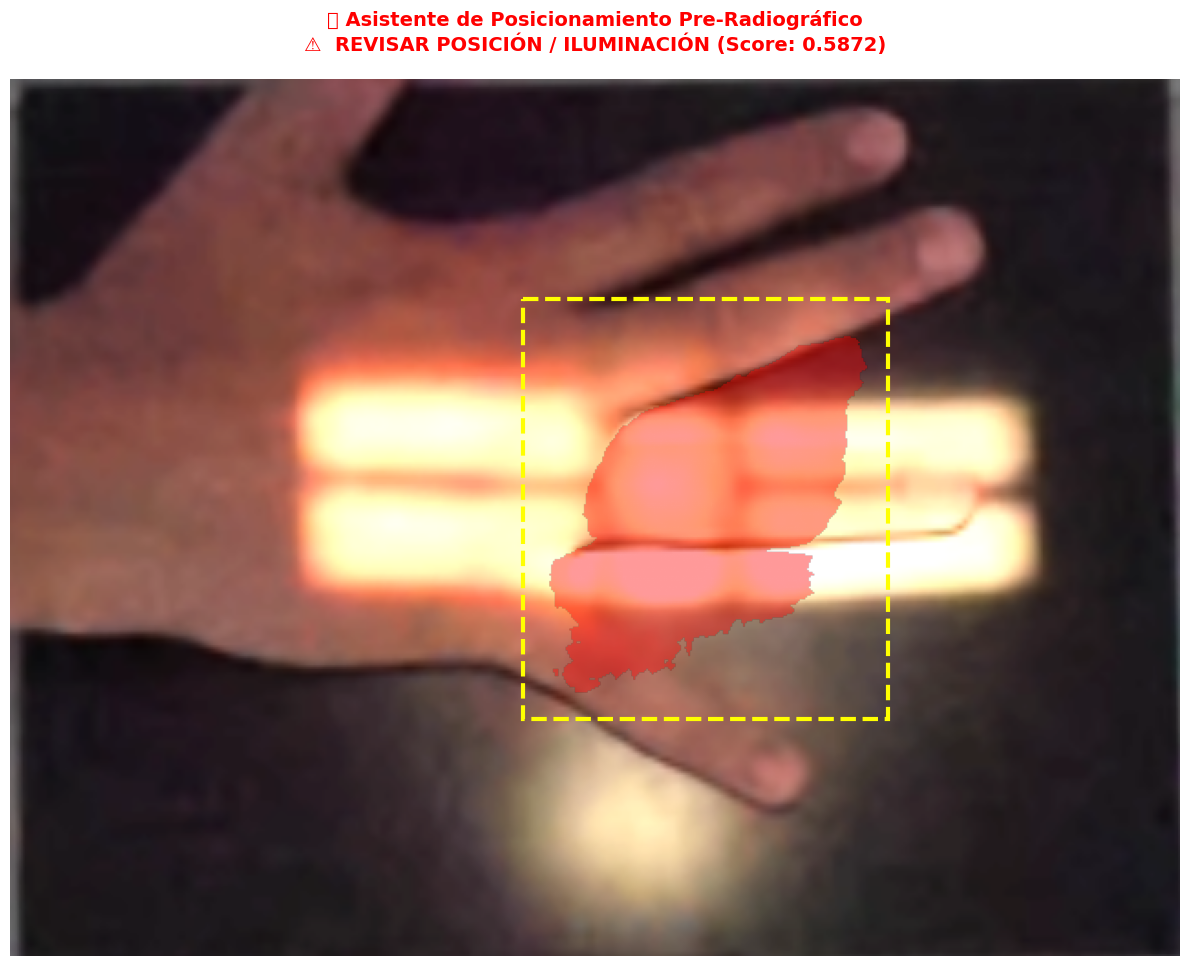

✅ Visualización completada


In [8]:
# --- VISUALIZACIÓN ---
print("⏳ Generando visualización...\n")

fig, ax = plt.subplots(figsize=(12, 12))

# 1. Mostrar imagen original
ax.imshow(image_np)

# 2. Superponer máscara de segmentación
mask = masks[0]
h, w = mask.shape[-2:]

# Color de la máscara (verde si válido, rojo si no)
rgba_color = np.array([0, 1, 0, 0.4]) if es_valido else np.array([1, 0, 0, 0.4])
mask_image = mask.reshape(h, w, 1) * rgba_color.reshape(1, 1, -1)
ax.imshow(mask_image)

# 3. Dibujar Bounding Box (simula colimación de rayos X)
x0, y0, x1, y1 = input_box
rect = plt.Rectangle(
    (x0, y0), 
    x1 - x0,  # ancho
    y1 - y0,  # altura
    edgecolor='yellow',
    facecolor='none',
    lw=3,
    linestyle='--',
    label='Campo de colimación'
)
ax.add_patch(rect)

# 4. Título con información para el técnico
title = f"🩻 Asistente de Posicionamiento Pre-Radiográfico\n{estado_txt} (Score: {score:.4f})"
ax.set_title(
    title,
    fontsize=14,
    color=color_display,
    fontweight='bold',
    pad=20
)

ax.axis('off')
plt.tight_layout()
plt.show()

print("✅ Visualización completada")

## 9️⃣ Resumen y Resultado Final

### Flujo Completado

```
1. ✅ Cargar modelo MedSAM pre-entrenado
2. ✅ Preparar imagen (encode con Vision Transformer)
3. ✅ Definir región de interés (bounding box)
4. ✅ Ejecutar segmentación
5. ✅ Validar posición radiográfica
6. ✅ Visualizar resultado con feedback
```

### Próximos Pasos Posibles
- 🔄 **Iterar**: Si sale rojo, mejorar iluminación y reintentar
- 📊 **Guardar resultado**: Exportar imagen con máscara para registro
- 🎯 **Ajustar umbral**: Cambiar 0.6 según sensibilidad deseada
- 🚀 **Automatizar**: Procesar múltiples imágenes en batch

In [9]:
# --- RESUMEN FINAL ---
print("\n" + "="*60)
print("📋 RESUMEN DEL ANÁLISIS")
print("="*60)
print(f"Modelo:          MedSAM ViT-B")
print(f"Dispositivo:     {device.upper()}")
print(f"Imagen:          {image_pil.size[0]}×{image_pil.size[1]} píxeles")
print(f"Región análisis: {input_box}")
print(f"Score:           {score:.4f}")
print(f"Umbral:          {umbral}")
print(f"Resultado:       {estado_txt}")
print("="*60)
print(f"\n✅ Análisis finalizado correctamente.")
print(f"📌 Recomendación para técnico: {estado_txt}")


📋 RESUMEN DEL ANÁLISIS
Modelo:          MedSAM ViT-B
Dispositivo:     CPU
Imagen:          640×480 píxeles
Región análisis: [280 120 480 350]
Score:           0.5872
Umbral:          0.6
Resultado:       ⚠️  REVISAR POSICIÓN / ILUMINACIÓN

✅ Análisis finalizado correctamente.
📌 Recomendación para técnico: ⚠️  REVISAR POSICIÓN / ILUMINACIÓN
